In [26]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Automatically detect project root
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

data_path = os.path.join(PROJECT_ROOT, "data", "raw", "WESAD", "S2", "S2.pkl")

with open(data_path, "rb") as f:
    data = pickle.load(f, encoding="latin1")

print("Loaded!")


C:\Users\danis\AppData\Local\Temp\ipykernel_49944\2310500658.py:10: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data = pickle.load(f, encoding="latin1")


Loaded!


In [17]:
data.keys()

dict_keys(['signal', 'label', 'subject'])

In [18]:
data["signal"].keys()

dict_keys(['chest', 'wrist'])

In [19]:
data["signal"]["chest"].keys()

dict_keys(['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp'])

In [20]:
ecg = data["signal"]["chest"]["ECG"].flatten()
resp = data["signal"]["chest"]["Resp"].flatten()
labels = data["label"].flatten()

In [21]:
len(ecg), len(resp), len(labels)

(4255300, 4255300, 4255300)

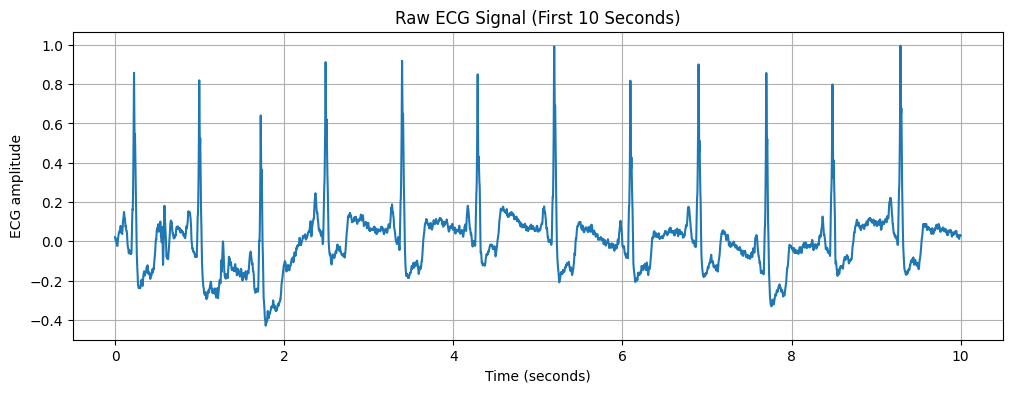

In [22]:
fs = 700
t = np.arange(0, 10 * fs) / fs

plt.figure(figsize=(12, 4))
plt.plot(t, ecg[:10 * fs])
plt.xlabel("Time (seconds)")
plt.ylabel("ECG amplitude")
plt.title("Raw ECG Signal (First 10 Seconds)")
plt.grid(True)
plt.show()


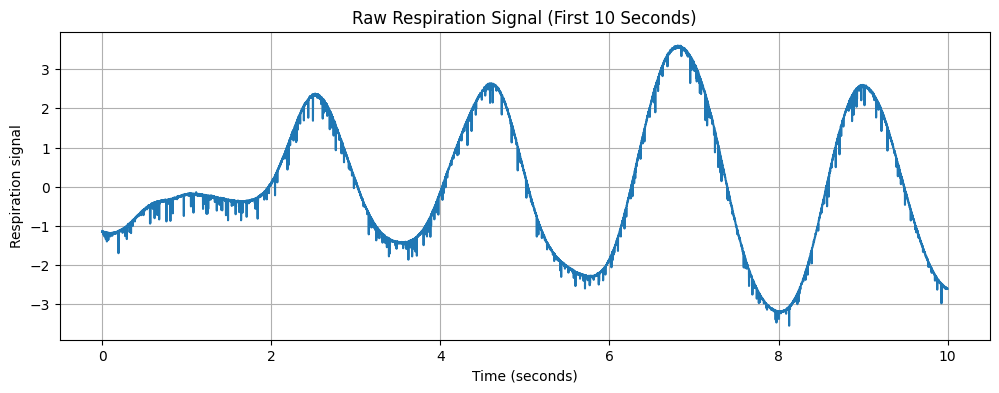

In [23]:
plt.figure(figsize=(12, 4))
plt.plot(t, resp[:10 * fs])
plt.xlabel("Time (seconds)")
plt.ylabel("Respiration signal")
plt.title("Raw Respiration Signal (First 10 Seconds)")
plt.grid(True)
plt.show()


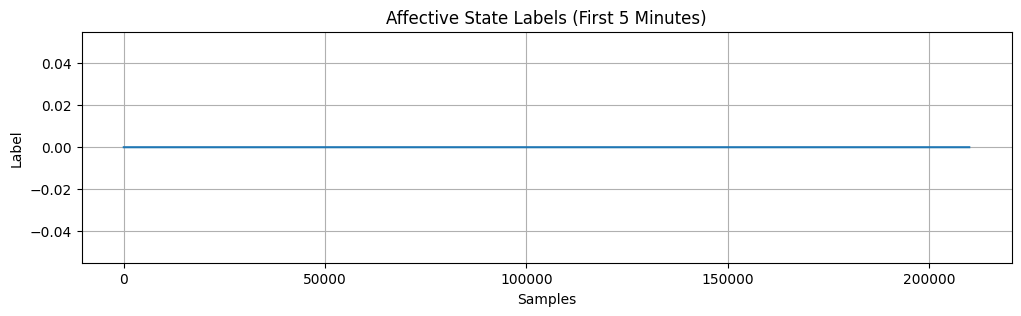

In [24]:
minutes = 5
samples = minutes * 60 * fs

plt.figure(figsize=(12, 3))
plt.plot(labels[:samples])
plt.xlabel("Samples")
plt.ylabel("Label")
plt.title("Affective State Labels (First 5 Minutes)")
plt.grid(True)
plt.show()


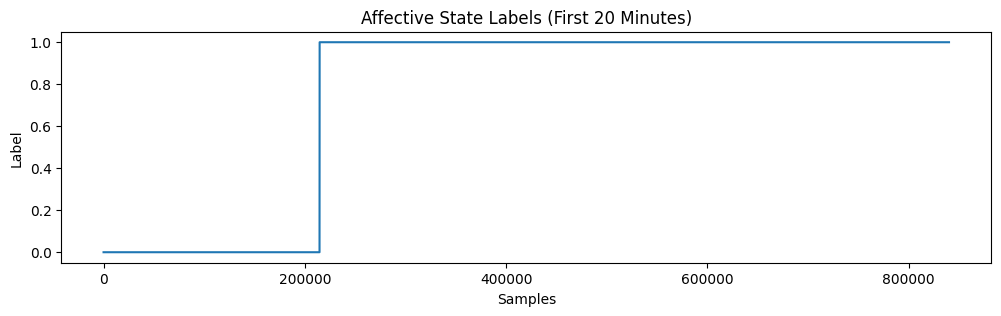

In [25]:
plt.figure(figsize=(12,3))
plt.plot(labels[:20*60*fs])  # first 20 minutes
plt.title("Affective State Labels (First 20 Minutes)")
plt.xlabel("Samples")
plt.ylabel("Label")
plt.show()


In [3]:
import pandas as pd
df = pd.read_csv('C:\Insights Tech Lab\Breath Gas Analytics\project_ml\data\processed\windows_features.csv')
print('=== windows_features.csv ===')
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print(df.head(3))
print('Nulls:', df.isnull().sum().sum())


=== windows_features.csv ===
Shape: (599, 8)
Columns: ['Subject', 'Label', 'Mean_RR', 'SDNN', 'RMSSD', 'Mean_HR', 'Resp_Rate', 'Resp_Variability']
  Subject  Label   Mean_RR      SDNN     RMSSD    Mean_HR  Resp_Rate  \
0     S10      1  0.725557  0.144507  0.140624  82.695032       79.5   
1     S10      1  0.685781  0.128872  0.082190  87.491522      103.5   
2     S10      1  0.859689  0.261279  0.266298  69.792645      100.0   

   Resp_Variability  
0          3.347959  
1          3.421302  
2          1.961128  
Nulls: 0


<>:2: SyntaxWarning: invalid escape sequence '\I'
<>:2: SyntaxWarning: invalid escape sequence '\I'
C:\Users\danis\AppData\Local\Temp\ipykernel_20036\332246140.py:2: SyntaxWarning: invalid escape sequence '\I'
  df = pd.read_csv('C:\Insights Tech Lab\Breath Gas Analytics\project_ml\data\processed\windows_features.csv')


In [5]:
import pandas as pd
df = pd.read_csv('C:\Insights Tech Lab\Breath Gas Analytics\project_ml\data\processed\windows_features_engineered.csv')
print('=== windows_features_engineered.csv ===')
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print(df.head(3))
print('Nulls:', df.isnull().sum().sum())


=== windows_features_engineered.csv ===
Shape: (599, 13)
Columns: ['Subject', 'Label', 'Mean_RR', 'SDNN', 'RMSSD', 'Mean_HR', 'Resp_Rate', 'Resp_Variability', 'Data_Source', 'Stress_State', 'HRV_HR_Ratio', 'Resp_Regularity', 'Autonomic_Index']
  Subject  Label   Mean_RR      SDNN     RMSSD    Mean_HR  Resp_Rate  \
0     S10      1  0.725557  0.144507  0.140624  82.695032       79.5   
1     S10      1  0.685781  0.128872  0.082190  87.491522      103.5   
2     S10      1  0.859689  0.261279  0.266298  69.792645      100.0   

   Resp_Variability Data_Source  Stress_State  HRV_HR_Ratio  Resp_Regularity  \
0          3.347959        Real             0      0.001701         0.298689   
1          3.421302        Real             0      0.000939         0.292286   
2          1.961128        Real             0      0.003816         0.509910   

   Autonomic_Index  
0       -82.409901  
1       -87.280459  
2       -69.265068  
Nulls: 0


<>:2: SyntaxWarning: invalid escape sequence '\I'
<>:2: SyntaxWarning: invalid escape sequence '\I'
C:\Users\danis\AppData\Local\Temp\ipykernel_20036\3478195535.py:2: SyntaxWarning: invalid escape sequence '\I'
  df = pd.read_csv('C:\Insights Tech Lab\Breath Gas Analytics\project_ml\data\processed\windows_features_engineered.csv')


In [7]:
import numpy as np
for f in ['X_train','X_test','y_train','y_test','X_train_eng','X_test_eng','y_train_eng','y_test_eng']:
    try:
        arr = np.load(f'C:\Insights Tech Lab\Breath Gas Analytics\project_ml\data\processed/{f}.npy', allow_pickle=True)
        print(f'{f}.npy — shape: {arr.shape}, dtype: {arr.dtype}', end='')
        if 'y' in f: print(f', unique: {np.unique(arr)}')
        else: print()
    except Exception as e:
        print(f'{f}.npy — ERROR: {e}')

X_train.npy — shape: (419, 6), dtype: float64
X_test.npy — shape: (180, 6), dtype: float64
y_train.npy — shape: (419,), dtype: int64, unique: [1 2 3]
y_test.npy — shape: (180,), dtype: int64, unique: [1 2 3]
X_train_eng.npy — shape: (419, 9), dtype: float64
X_test_eng.npy — shape: (180, 9), dtype: float64
y_train_eng.npy — shape: (419,), dtype: int64, unique: [0 1]
y_test_eng.npy — shape: (180,), dtype: int64, unique: [0 1]


<>:4: SyntaxWarning: invalid escape sequence '\I'
<>:4: SyntaxWarning: invalid escape sequence '\I'
C:\Users\danis\AppData\Local\Temp\ipykernel_20036\1945081533.py:4: SyntaxWarning: invalid escape sequence '\I'
  arr = np.load(f'C:\Insights Tech Lab\Breath Gas Analytics\project_ml\data\processed/{f}.npy', allow_pickle=True)
